<a href="https://colab.research.google.com/github/arshaknihal/Exit-Exam-/blob/main/Exit_Examination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Libraries**

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import io
import zipfile
import hashlib
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Load Dataset

In [38]:
 from google.colab import drive
 drive.mount('/content/drive')
 ZIP_PATH = "/content/drive/MyDrive/Exit Exam/Dataset/mudra.zip"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
EXTRACT_DIR = Path("/content/bharatanatyam_mudras")

if EXTRACT_DIR.exists():
    import shutil
    shutil.rmtree(EXTRACT_DIR)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)


Extracted to: /content/bharatanatyam_mudras


In [53]:
dataset_folder = EXTRACT_DIR
folders = [
    folder for folder in dataset_folder.iterdir()
    if folder.is_dir()
]
if len(folders) == 1:
    dataset_folder = folders[0]
class_folders = sorted([
    folder for folder in dataset_folder.iterdir()
    if folder.is_dir()
])
classes = [folder.name for folder in class_folders]
print("Dataset folder:", dataset_folder)
print("Classes:", classes)
print("Number of classes:", len(classes))

Dataset folder: /content/bharatanatyam_mudras/Bharatanatyam_Mudras
Classes: ['Musti', 'Pataka', 'Sikhara', 'Simhamukha', 'Trisula']
Number of classes: 5


In [55]:
image_extensions = [
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
]
class_counts = {}
for folder in class_folders:
    count = 0
    for file in folder.rglob("*"):
        if file.suffix.lower() in image_extensions:
            count += 1
    class_counts[folder.name] = count
for class_name, count in class_counts.items():
    print(class_name, ":", count)

Musti : 400
Pataka : 400
Sikhara : 400
Simhamukha : 400
Trisula : 400


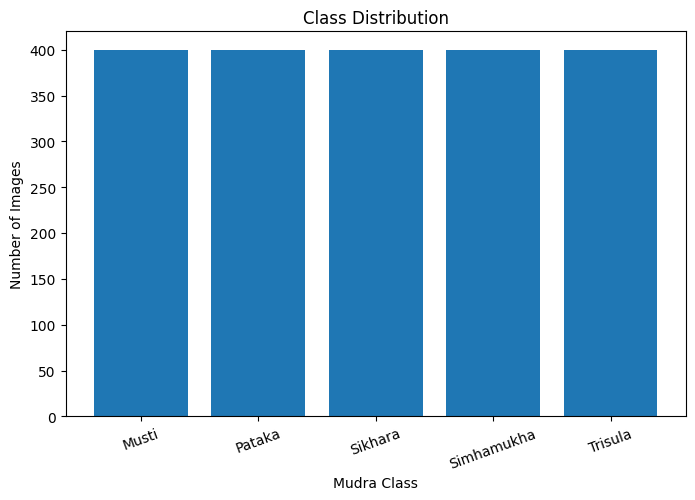

In [57]:
plt.figure(figsize=(8, 5))
plt.bar(
    class_counts.keys(),
    class_counts.values()
)
plt.xlabel("Mudra Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.xticks(rotation=20)
plt.show()


In [58]:
image_data = []
corrupted_images = []
for class_folder in class_folders:
    for image_file in class_folder.rglob("*"):
        if image_file.suffix.lower() not in image_extensions:
            continue
        try:
            with Image.open(image_file) as image:
                image.verify()
            with Image.open(image_file) as image:
                image_data.append({
                    "file": str(image_file),
                    "class": class_folder.name,
                    "width": image.width,
                    "height": image.height,
                    "format": image.format,
                    "mode": image.mode,
                    "aspect_ratio": image.width / image.height
                })
        except Exception as error:
            corrupted_images.append({
                "file": str(image_file),
                "error": str(error)
            })
image_df = pd.DataFrame(image_data)
corrupted_df = pd.DataFrame(corrupted_images)
print("Valid images:", len(image_df))
print("Corrupted images:", len(corrupted_df))
image_df.head()

Valid images: 2000
Corrupted images: 0


,file,class,width,height,format,mode,aspect_ratio
0,/content/bharatanatyam_mudras/Bharatanatyam_Mu...,Musti,300,300,JPEG,RGB,1.0
1,/content/bharatanatyam_mudras/Bharatanatyam_Mu...,Musti,300,300,JPEG,RGB,1.0
2,/content/bharatanatyam_mudras/Bharatanatyam_Mu...,Musti,300,300,JPEG,RGB,1.0
3,/content/bharatanatyam_mudras/Bharatanatyam_Mu...,Musti,300,300,JPEG,RGB,1.0
4,/content/bharatanatyam_mudras/Bharatanatyam_Mu...,Musti,300,300,JPEG,RGB,1.0


In [60]:
print("Image dimensions:")
print(image_df[["width", "height"]].value_counts())
print("\nImage formats:")
print(image_df["format"].value_counts())
print("\nColor modes:")
print(image_df["mode"].value_counts())
print("\nAspect ratio:")
print(image_df["aspect_ratio"].describe())

Image dimensions:
width  height
300    300       2000
Name: count, dtype: int64

Image formats:
format
JPEG    2000
Name: count, dtype: int64

Color modes:
mode
RGB    2000
Name: count, dtype: int64

Aspect ratio:
count    2000.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64


In [61]:
if len(corrupted_df) == 0:
    print("No corrupted images found.")
else:
    display(corrupted_df)

No corrupted images found.


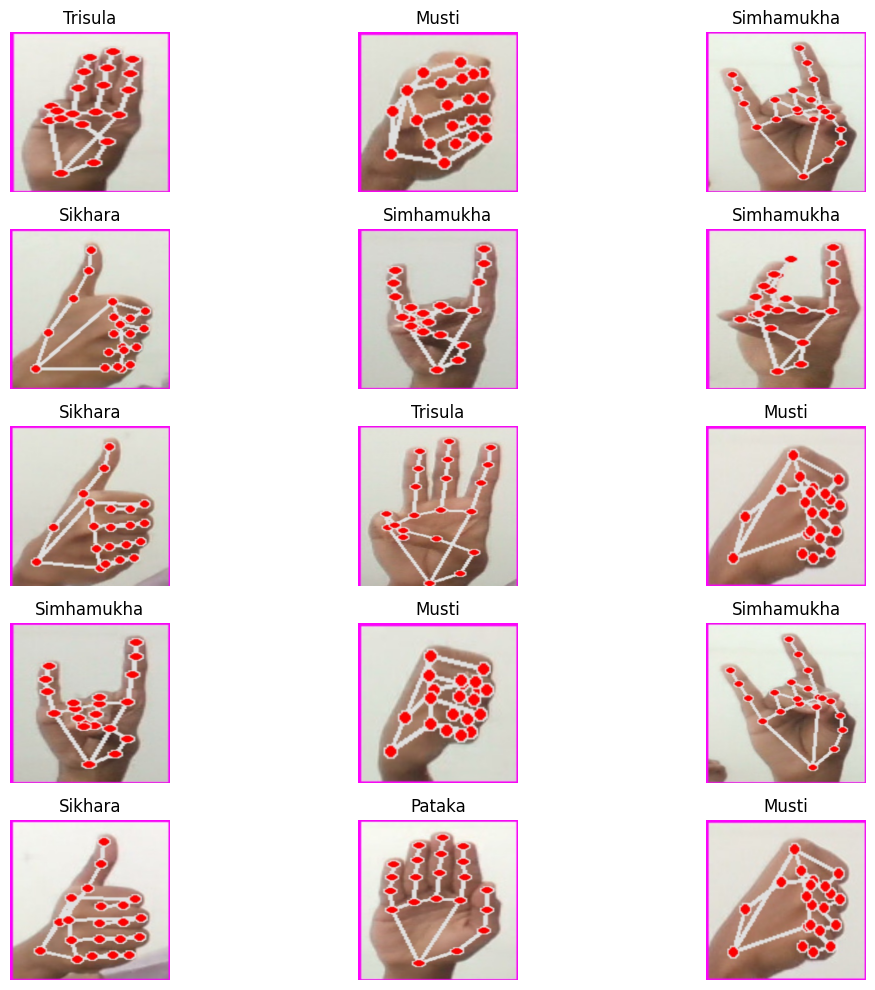

In [62]:
plt.figure(figsize=(12, 10))
sample_images = image_df.sample(
    15,
    random_state=42
)
for i, (_, row) in enumerate(sample_images.iterrows()):
    image = Image.open(row["file"])
    plt.subplot(5, 3, i + 1)
    plt.imshow(image)
    plt.title(row["class"])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [70]:
train_data, remaining_data = train_test_split(
    image_df,
    test_size=0.30,
    stratify=image_df["class"],
    random_state=42
)
validation_data, test_data = train_test_split(
    remaining_data,
    test_size=0.50,
    stratify=remaining_data["class"],
    random_state=42
)
train_data = train_data.reset_index(drop=True)
validation_data = validation_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)
print("Training:", len(train_data))
print("Validation:", len(validation_data))
print("Test:", len(test_data))

Training: 1400
Validation: 300
Test: 300


In [73]:
print("Training distribution:")
print(train_data["class"].value_counts().sort_index())
print("\nValidation distribution:")
print(validation_data["class"].value_counts().sort_index())
print("\nTest distribution:")
print(test_data["class"].value_counts().sort_index())

Training distribution:
class
Musti         280
Pataka        280
Sikhara       280
Simhamukha    280
Trisula       280
Name: count, dtype: int64

Validation distribution:
class
Musti         60
Pataka        60
Sikhara       60
Simhamukha    60
Trisula       60
Name: count, dtype: int64

Test distribution:
class
Musti         60
Pataka        60
Sikhara       60
Simhamukha    60
Trisula       60
Name: count, dtype: int64


### Task 2 Preprocessing and augmentation

In [74]:
def load_image(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(
        image,
        image_size
    )
    image = tf.cast(
        image,
        tf.float32
    ) / 255.0
    return image, label

In [78]:
augmentation = keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(
        height_factor=0.08,
        width_factor=0.08
    ),
    layers.RandomContrast(0.10)
])
print("Augmentation pipeline created.")

Augmentation pipeline created.


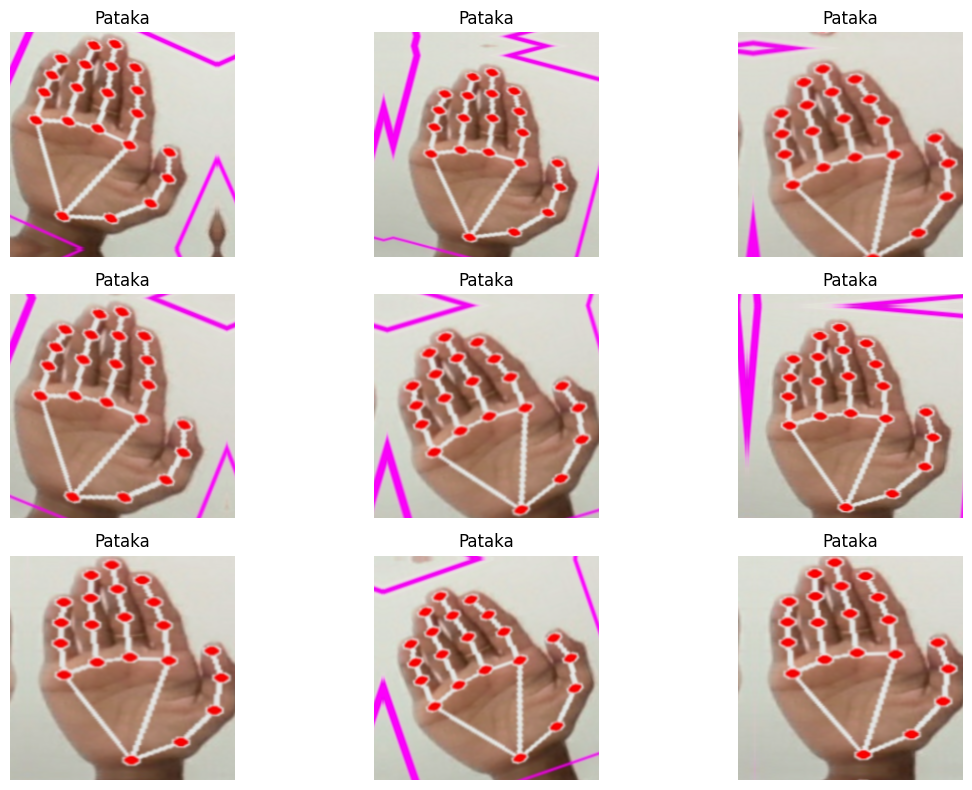

In [86]:
image_size = (224, 224)
class_to_index = {cls_name: i for i, cls_name in enumerate(classes)}
number_to_class = {i: cls_name for i, cls_name in enumerate(classes)}
train_filepaths = train_data['file'].values
train_labels_str = train_data['class'].values
train_labels_int = np.array([class_to_index[label] for label in train_labels_str])
train_dataset = tf.data.Dataset.from_tensor_slices((train_filepaths, train_labels_int))
train_dataset = train_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(32)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
for images, labels in train_dataset.take(1):
    original_image = images[0]
    original_label = labels[0].numpy()
    plt.figure(figsize=(12, 8))
    for i in range(9):
        new_image = augmentation(
            tf.expand_dims(
                original_image,
                0
            ),
            training=True
        )[0]
        plt.subplot(3, 3, i + 1)
        plt.imshow(
            tf.clip_by_value(
                new_image,
                0,
                1
            )
        )
        plt.title(
            number_to_class[original_label]
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

### Task 3 : CNN Development

In [87]:
def create_cnn(
    learning_rate=0.001,
    dropout=0.5
):
    model = keras.Sequential([
        augmentation,
        layers.Conv2D(
            32,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),
        layers.Conv2D(
            64,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),
        layers.Conv2D(
            128,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),
        layers.Conv2D(
            256,
            (3, 3),
            activation="relu",
            padding="same"
        ),
        layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(
            128,
            activation="relu"
        ),
        layers.Dropout(dropout),
        layers.Dense(
            len(classes),
            activation="softmax"
        )
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model
model = create_cnn()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 224, 224, 32)      │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 112, 112, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 112, 112, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 56, 56, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 56, 56, 128)       │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (1, 28, 28, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 28, 28, 256)       │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (1, 14, 14, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 256)               │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 128)               │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 128)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 5)                 │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,957 (1.61 MB)

 Trainable params: 421,957 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [96]:
validation_filepaths = validation_data['file'].values
validation_labels_str = validation_data['class'].values
validation_labels_int = np.array([class_to_index[label] for label in validation_labels_str])
test_filepaths = test_data['file'].values
test_labels_str = test_data['class'].values
test_labels_int = np.array([class_to_index[label] for label in test_labels_str])
validation_dataset = tf.data.Dataset.from_tensor_slices((validation_filepaths, validation_labels_int))
validation_dataset = validation_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.batch(32)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = tf.data.Dataset.from_tensor_slices((test_filepaths, test_labels_int))
test_dataset = test_dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=6,
    restore_best_weights=True
)
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=1,
    callbacks=[early_stop]
)

44/44 ━━━━━━━━━━━━━━━━━━━━ 177s 4s/step - accuracy: 0.5886 - loss: 0.9352 - val_accuracy: 0.6967 - val_loss: 0.7384


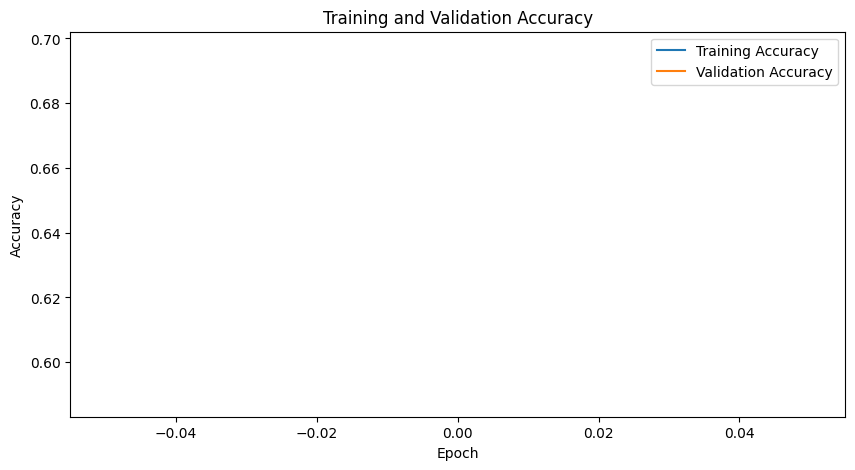

In [98]:
plt.figure(figsize=(10, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

### Task 4 Model Evaluation and failure analysis

In [97]:
actual_labels = []
predicted_labels = []
confidence_scores = []
for images, labels in test_dataset:
    predictions = model.predict(
        images,
        verbose=0
    )
    predicted = np.argmax(
        predictions,
        axis=1
    )
    confidence = np.max(
        predictions,
        axis=1
    )
    actual_labels.extend(labels.numpy())
    predicted_labels.extend(predicted)
    confidence_scores.extend(confidence)
actual_labels = np.array(actual_labels)
predicted_labels = np.array(predicted_labels)
confidence_scores = np.array(confidence_scores)
print("Test predictions completed.")

Test predictions completed.


In [101]:
accuracy = accuracy_score(
    actual_labels,
    predicted_labels
)
precision = precision_score(
    actual_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    actual_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    actual_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.6667
Precision: 0.6373
Recall   : 0.6667
F1 Score : 0.6211


In [100]:
print(
    classification_report(
        actual_labels,
        predicted_labels,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)


              precision    recall  f1-score   support

       Musti     1.0000    1.0000    1.0000        60
      Pataka     0.5000    1.0000    0.6667        60
     Sikhara     1.0000    0.8833    0.9381        60
  Simhamukha     0.2500    0.0500    0.0833        60
     Trisula     0.4364    0.4000    0.4174        60

    accuracy                         0.6667       300
   macro avg     0.6373    0.6667    0.6211       300
weighted avg     0.6373    0.6667    0.6211       300



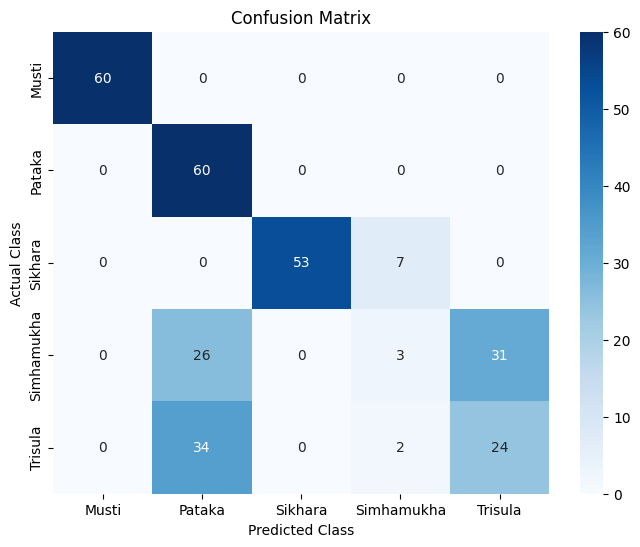

In [99]:
confusion = confusion_matrix(
    actual_labels,
    predicted_labels
)
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

In [102]:
test_results = test_data.copy()
test_results["actual"] = [
    number_to_class[number]
    for number in actual_labels
]
test_results["predicted"] = [
    number_to_class[number]
    for number in predicted_labels
]
test_results["confidence"] = confidence_scores
wrong_predictions = test_results[
    test_results["actual"] != test_results["predicted"]
].copy()
print(
    "Total incorrect predictions:",
    len(wrong_predictions)
)

Total incorrect predictions: 100


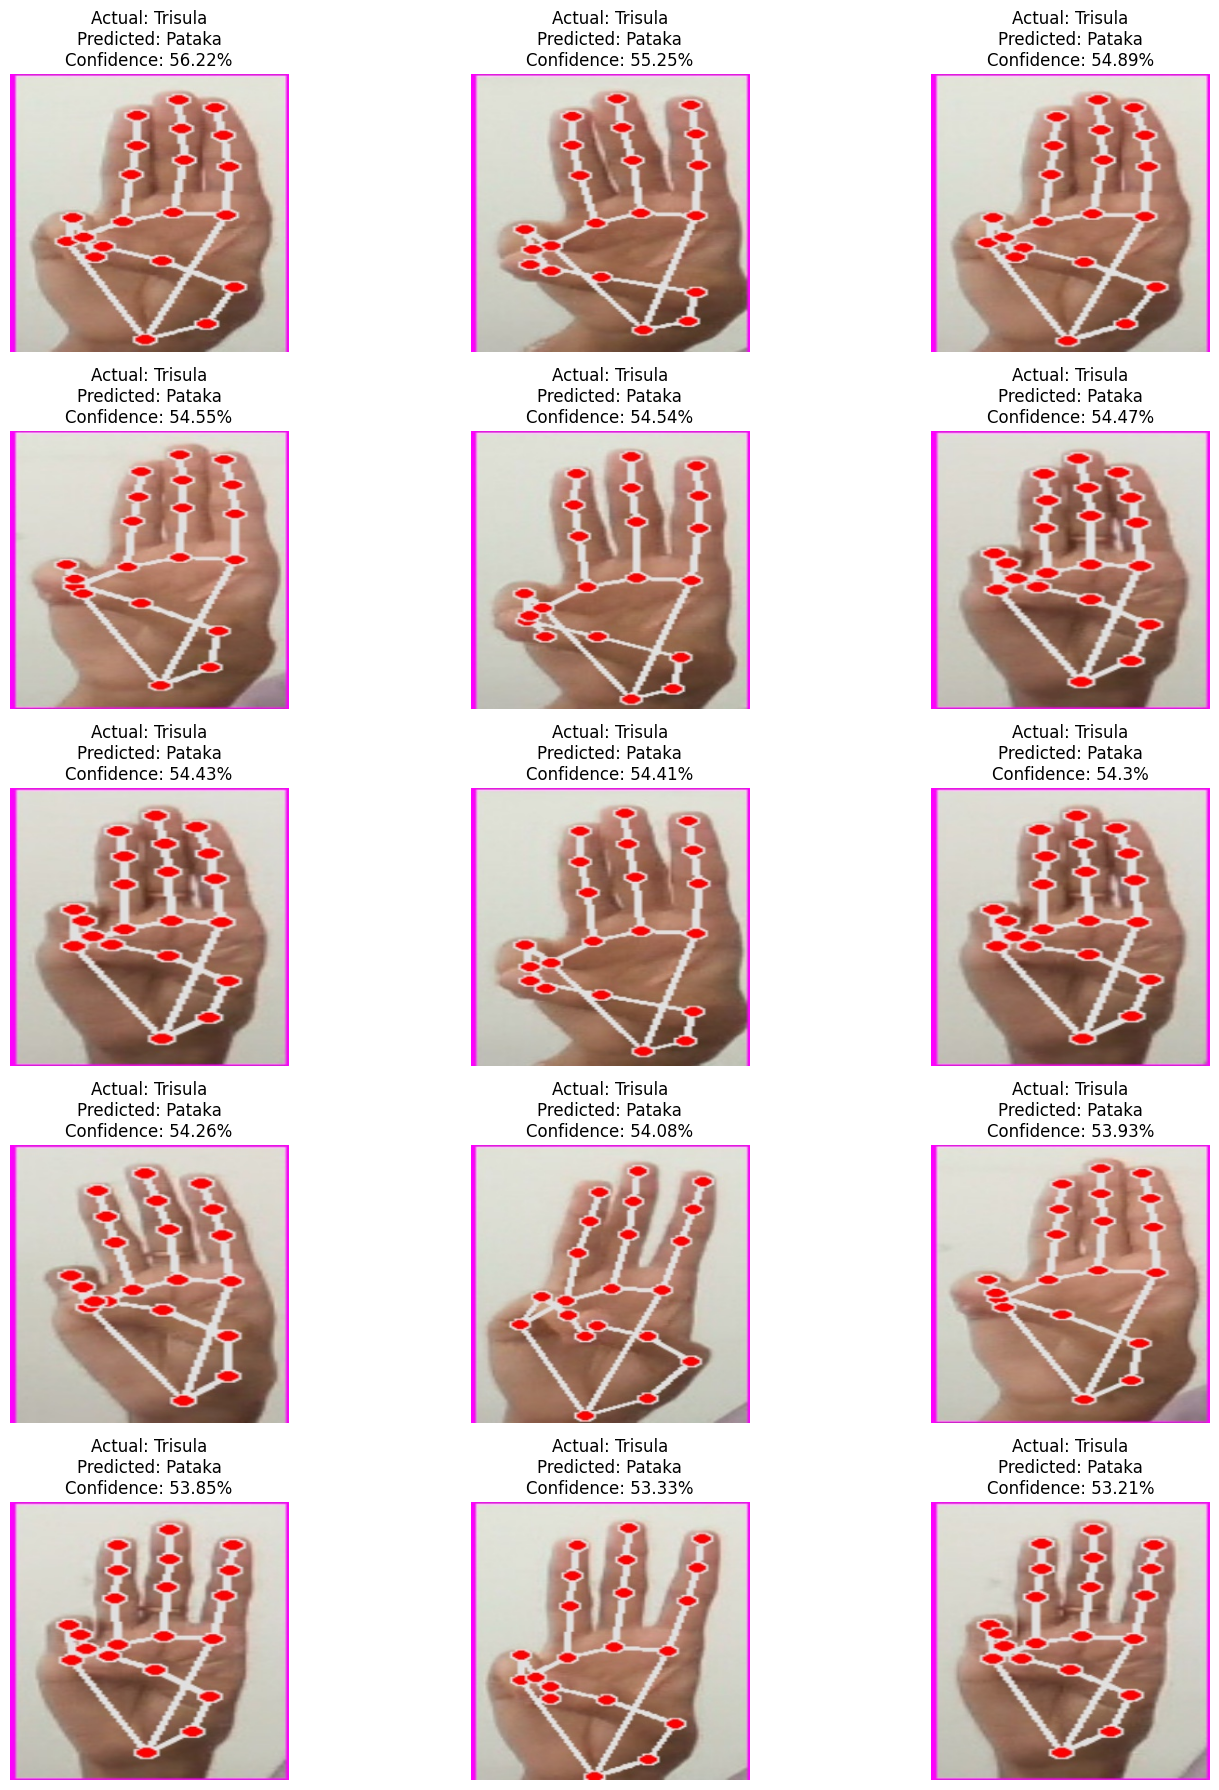

In [103]:
wrong_predictions = wrong_predictions.sort_values(
    "confidence",
    ascending=False
)
number_to_show = min(
    15,
    len(wrong_predictions)
)
plt.figure(figsize=(15, 18))
for i in range(number_to_show):
    row = wrong_predictions.iloc[i]
    image = Image.open(
        row["file"]
    )
    plt.subplot(5, 3, i + 1)
    plt.imshow(image)
    plt.title(
        "Actual: " + row["actual"] +
        "\nPredicted: " + row["predicted"] +
        "\nConfidence: " +
        str(round(row["confidence"] * 100, 2)) + "%"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

In [104]:
error_pairs = (
    wrong_predictions
    .groupby(
        ["actual", "predicted"]
    )
    .size()
    .reset_index(
        name="number_of_errors"
    )
    .sort_values(
        "number_of_errors",
        ascending=False
    )
)
display(error_pairs)

,actual,predicted,number_of_errors
3,Trisula,Pataka,34
2,Simhamukha,Trisula,31
1,Simhamukha,Pataka,26
0,Sikhara,Simhamukha,7
4,Trisula,Simhamukha,2


In [106]:
model_path = "/content/bharatanatyam_mudra_cnn.keras"
model.save(model_path)
print("Model saved at:", model_path)

Model saved at: /content/bharatanatyam_mudra_cnn.keras
